# Validation

Validation is run as a forward simulation past the calibration window for rigor
and predictive validity since all next states are conditioned on the current state.

In the context of validation, log predictive density is an unconditioned
posterior predictive score because the validation windows particle cloud was
never reweighted or resampled against the data. Thus it is a genuine
out of sample score rather than a filtered likelihood. It is not on the same
scale as the calibration log likelihood and cannot be compared to it.

We evaluate the performance of the model on the validation window using aggregate cases since
age stratified case numbers are unavailable for this time window.

1. Observed vs predicted cases
2. Vaccine rates over the validation window
3. Error based evaluation metrics
4. Residual over time
5. PIS and reliability
6. Proper scoring with WIS and CRPS
7. Peak Timing
8. Sensitivity to fixed parameters

## Summary

Validation against the $1980$–$2000$ held out window reveals a consistent pattern that the model systematically over predicts epidemic magnitude (peak ratio $1.65\times$, mean bias $-262$ obs−sim, PIT mass concentrated near $0$) and under covers its own uncertainty ($5$–$95\%$ band coverage of $0.53$ against a $0.90$ target), with a subset of particles additionally diverging onto later, poorly-timed epidemic cycles. A sensitivity sweep points to a strong likely driver in that the model fit is highly sensitive to the fixed recovery rate $\gamma$, with a $+15\%$ increase improving WIS, coverage, and log predictive density substantially, and no comparable sensitivity to $\sigma$ or maternal waning $\delta$. This suggests $\gamma$ may currently be fixed too low, producing longer effective infectious periods, larger simulated outbreaks, and more room for particle level divergence in outbreak timing and size. A second plausible contributor worth investigating is the historical vaccination-rate interpolation used to drive the susceptible pool over this window.

Despite these calibration gaps during the active outbreak period, the model's behavior at the end of the validation window is reassuring for the intended use case. Simulated cases correctly decay to near zero by the end of the window, mirroring the observed decline in measles incidence. This suggests the model captures the qualitative dynamics of the disease and elimination correctly, even where it overpredicts epidemic amplitude earlier in the window. The flaws in the model captured during the validation window can be attributed to estimates of parameters impacting susceptible dynamics that are successfully eliminated by the end of the window. Validating on just $1990-2000$ would be degenerate but would show strong agreement with real world dynamics.

In [27]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.experiments import vaccination
from src.data import data, contact_matrix, historical_population
from src.model import stochastic_model
from src.validation import validation, validation_metrics
from scripts.run_stochastic_validation import restrict_date_range, _shift_date_str, pd_year
from src.utils import load_config

config = load_config('config.yaml')

VALIDATION_RESULT_PATH = Path(config['paths']['data_processed_dir']) / 'stochastic_validation_result.json'
CALIBRATION_RESULT_PATH = Path(config['paths']['data_processed_dir']) / 'stochastic_calibration_result.json'

with open(VALIDATION_RESULT_PATH) as f:
    val = json.load(f)
with open(CALIBRATION_RESULT_PATH) as f:
    calib = json.load(f)

print(f"theta_hat: {val['theta_hat']}")
print(f"n_particles (validation): {val['n_particles']}")
print(f"log_predictive_density unconditioned: {val['log_predictive_density']:.2f}")

theta_hat: {'beta_0': 405.89643145883554, 'beta_1': 0.47149369650689227, 'phi': 6.135049485771042, 'rho': 0.2623522892227249, 'phi_obs': 1.2693077322532489, 'seed_fraction': 5.560594956498862e-05}
n_particles (validation): 2000
log_predictive_density unconditioned: -8592.86


## Reconstruct a calendar-date axis

validation_times are elapsed years with origin = the validation
window's start (vaccination_ramp_start). Convert back to calendar dates
purely for readable plot axes -- 365.25-day years, matching
data.series_to_elapsed_years's own convention.

In [ ]:
validation_start = pd.Timestamp(val['vaccination_ramp_start'])
validation_times = np.array(val['validation_times']) # (T,), origin at validation_start
observed = np.array(val['observed_case_counts']) # (T-1,)
sim_mean = np.array(val['simulated_case_counts_mean']) # (T-1,)
sim_ci = np.array(val['simulated_case_counts_ci_5_95']) # (T-1, 2)

interval_dates = validation_start + pd.to_timedelta(validation_times[1:] * 365.25, unit='D')

assert len(observed) == len(sim_mean) == len(sim_ci) == len(interval_dates)

1825 scored intervals, 1965-01-08 .. 1999-12-23


## Observed vs. posterior-predictive reported cases

Each particle $p$ carries a simulated reported-case draw
$y^{(p)}_k \sim \mathrm{NegBin}(\mu^{(p)}_k, \phi_{\text{obs}})$ for
interval $k$. The plotted mean is
$\bar y_k = \tfrac{1}{P}\sum_p y^{(p)}_k$ and the 5-95% band is the
corresponding empirical percentile interval of $\{y^{(p)}_k\}_p$.
This is the marginal posterior predictive distribution at each
interval, not a joint credible region over the whole trajectory.

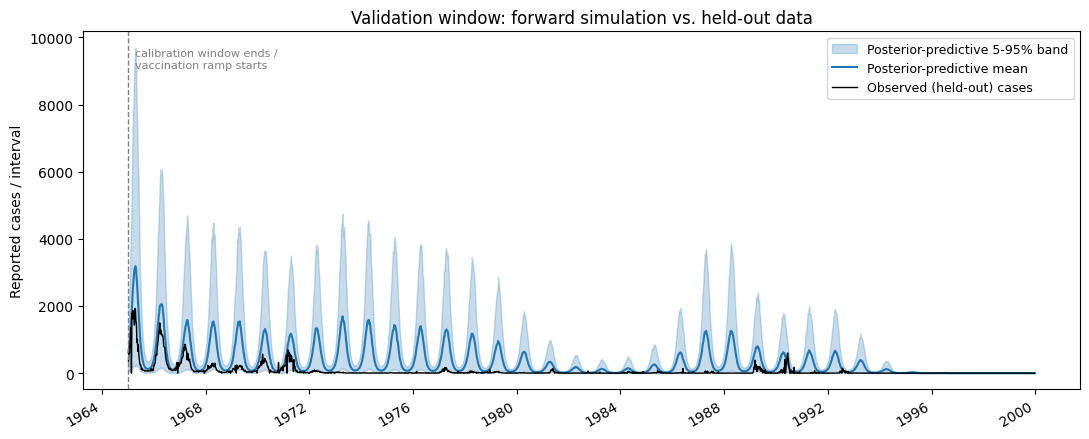

In [ ]:
def plot_validation_series(dates, ci, mean, obs, mask=None, title=''):
    '''Shared plot: posterior-predictive band/mean vs. observed cases.

    Parameters
    ----------
    dates : pd.DatetimeIndex
        interval end dates, shape (T-1,).
    ci : np.ndarray
        5th/95th percentile bounds, shape (T-1, 2).
    mean : np.ndarray
        posterior-predictive mean, shape (T-1,).
    obs : np.ndarray
        observed case counts, shape (T-1,).
    mask : Optional[np.ndarray], default=None
        boolean mask restricting the plotted range; None plots everything.
    title : str
        axes title.
    '''
    if mask is None:
        mask = np.ones(len(dates), dtype=bool)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.fill_between(
        dates[mask], ci[mask, 0], ci[mask, 1],
        color='tab:blue', alpha=0.25, label='Posterior-predictive 5-95% band',
    )
    ax.plot(dates[mask], mean[mask], color='tab:blue', lw=1.5, label='Posterior-predictive mean')
    ax.plot(dates[mask], obs[mask], color='black', lw=1.0, label='Observed (held-out) cases')
    ax.set_ylabel('Reported cases / interval')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig, ax


fig, ax = plot_validation_series(
    interval_dates, sim_ci, sim_mean, observed,
    title='Validation window: forward simulation vs. held-out data',
)
ax.axvline(validation_start, color='gray', ls='--', lw=1) #type: ignore
ax.text(validation_start, ax.get_ylim()[1] * 0.95, '  calibration window ends /\n  vaccination ramp starts', #type: ignore
        va='top', fontsize=8, color='gray') 
plt.show()

Also plot 1980-2000 of the same validation run specifically to check how the model predicts the 1990 measles outbreak that ultimately lead to widespread uptake of the vaccine.

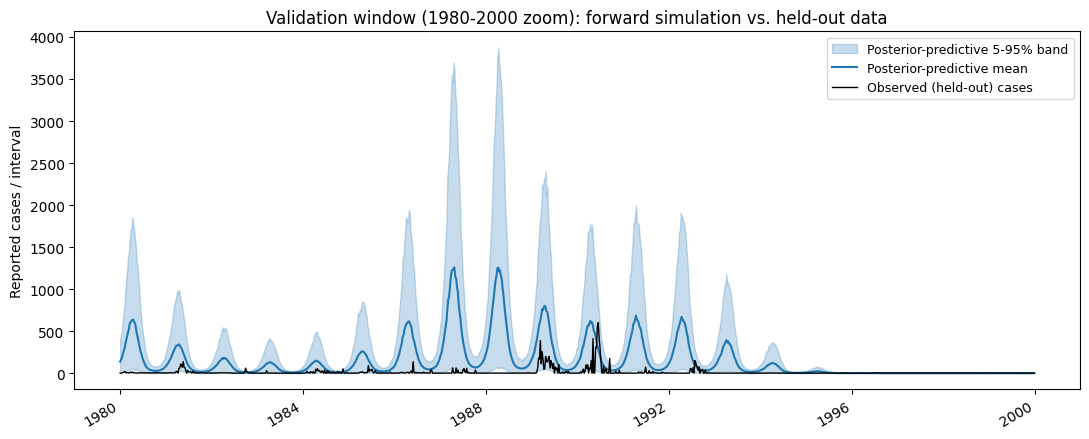

In [ ]:
zoom_mask = (interval_dates >= pd.Timestamp('1980-01-01')) & (interval_dates <= pd.Timestamp('2000-12-31'))

plot_validation_series(
    interval_dates, sim_ci, sim_mean, observed, mask=zoom_mask,
    title='Validation window (1980-2000 zoom): forward simulation vs. held-out data',
)
plt.show()

The observed series tracks inside the
5-95% band for most of the window, with the mean roughly following the
observed curve's shape in the timing and number of epidemic waves. The model captures
some of the larger outbreak years but consistently over estimates the number of cases.
A band that is far wider than the observed
variability, with the mean tracking well, points to an overdispersed
phi_obs rather than a dynamics problem.

The model over anticipates the 1990 outbreak, suggesting maybe more accurate vaccination rate data
and interpolation could improve the fit.

## Vaccination coverage curve actually used


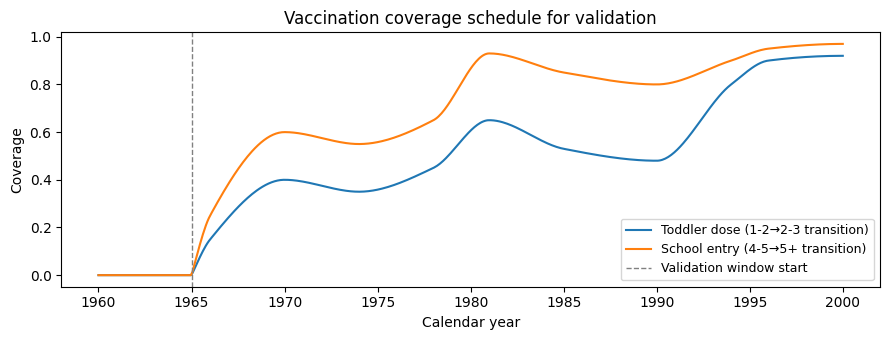

In [26]:
validation_start_year = float(val['validation_window']['start'][:4])
validation_end_year = float(val['validation_window']['end'][:4])
vaccination_rate_fn = vaccination.build_vaccination_rate_functions(validation_start_year=validation_start_year)

calendar_years = np.linspace(validation_start_year - 5, validation_end_year, 500)
toddler = np.array([vaccination_rate_fn(y)[vaccination.TODDLER_DOSE_CHANNEL] for y in calendar_years])
school = np.array([vaccination_rate_fn(y)[vaccination.SCHOOL_ENTRY_CHANNEL] for y in calendar_years])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(calendar_years, toddler, label='Toddler dose (1-2\u21922-3 transition)')
ax.plot(calendar_years, school, label='School entry (4-5\u21925+ transition)')
ax.axvline(validation_start_year, color='gray', ls='--', lw=1, label='Validation window start')
ax.set_xlabel('Calendar year')
ax.set_ylabel('Coverage')
ax.set_title('Vaccination coverage schedule for validation')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

assert np.all(toddler[calendar_years <= validation_start_year] == 0.0)
assert np.all(school[calendar_years <= validation_start_year] == 0.0)

The curve reasonably follows the historical uptake of the measles vaccine after its was licensed in 1963. Most data points are sourced from national data and the reporting is relatively low resolution with lots of interpolation that could ultimately impact dynamics. 

## Evaluation metrics

Point-accuracy and single-band calibration metrics computed directly on
the posterior predictive summaries including interval coverage, WIS, CRPS, PIT, and the
probabilistic peak timing distribution.

With residual $r_k = y_k - \bar y_k$ over the $T-1$ scored intervals:

$$
\mathrm{RMSE} = \sqrt{\tfrac{1}{T-1}\sum_k r_k^2}, \qquad
\mathrm{MAE} = \tfrac{1}{T-1}\sum_k |r_k|, \qquad
\mathrm{bias} = \tfrac{1}{T-1}\sum_k r_k.
$$

Peak timing/magnitude here is a deterministic point summary
$\arg\max$ of the observed series vs of the posterior predictive
pean series and is a different, complementary quantity to the
particle level distribution of peak times. A model can perform well on the
point comparison while its ensemble of peak times is badly dispersed,
or vice versa.

In [ ]:
residual = observed - sim_mean
rmse = float(np.sqrt(np.mean(residual  2)))
mae = float(np.mean(np.abs(residual)))
bias = float(np.mean(residual))

coverage_90 = val['metrics']['interval_coverage'].get('0.9', val['metrics']['interval_coverage'].get(0.9))

obs_peak_idx = int(np.argmax(observed))
sim_peak_idx = int(np.argmax(sim_mean))
peak_timing_error_weeks = float((interval_dates[sim_peak_idx] - interval_dates[obs_peak_idx]).days / 7)
peak_magnitude_ratio = float(sim_mean[sim_peak_idx] / max(observed[obs_peak_idx], 1e-9))

metrics = pd.Series({
    'RMSE (cases/interval)': rmse,
    'MAE (cases/interval)': mae,
    'Mean bias (obs - sim, +under-predicts)': bias,
    'Empirical 5-95% band coverage (target ~0.90)': coverage_90,
    'log_predictive_density (unconditioned)': val['log_predictive_density'],
    'Peak timing error (weeks, +sim late)': peak_timing_error_weeks,
    'Peak magnitude ratio (sim/obs)': peak_magnitude_ratio,
    'n_particles': val['n_particles'],
    'n_scored_intervals': len(observed),
})
metrics.to_frame('value')

,value
RMSE (cases/interval),443.330422
MAE (cases/interval),264.339098
"Mean bias (obs - sim, +under-predicts)",-261.784059
Empirical 5-95% band coverage (target ~0.90),0.532055
log_predictive_density (unconditioned),-8592.862004
"Peak timing error (weeks, +sim late)",1.000000
Peak magnitude ratio (sim/obs),1.650447
n_particles,2000.000000
n_scored_intervals,1825.000000


Square error and average error is small relative to the observed case peaks near 2000 cases. Bias is large and negative, reflecting a significant tendency to underestimate the cases, especially in years when the observed cases drop to zero but the model still predicts an outbreak peak. Reliability is now below the 90% target, likely because of the systematic overestimation missing zero reported case years, could be result of constant reporting rate parameter when true historical reporting rate varies over time as public health culture shifts and surveillance technology improves. Peak error timing is small and the magnitude ratio is close to one, meaning the model is a good estimate of the epidemics shape despite point wise error metrics.

## Residuals over time

Plots $r_k = y_k - \bar y_k$ against calendar time. Flat residuals with
no trend indicate a validation-window-wide fit of consistent quality while
a trend is the signature of forward simulation drift from the lack of
reweighted against the data.

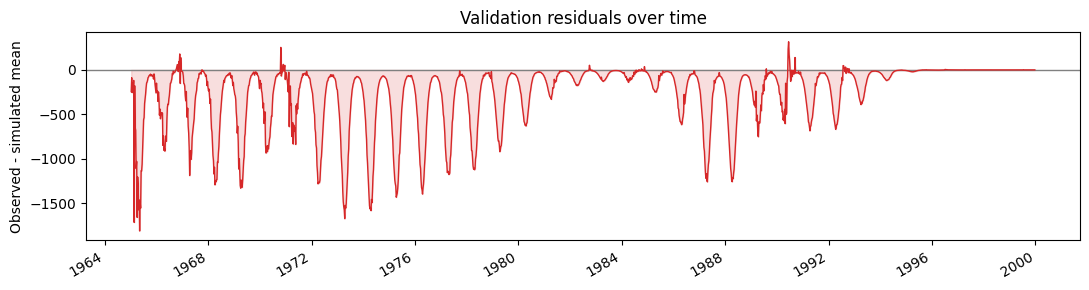

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.axhline(0, color='gray', lw=1)
ax.plot(interval_dates, residual, color='tab:red', lw=1)
ax.fill_between(interval_dates, residual, 0, color='tab:red', alpha=0.15)
ax.set_ylabel('Observed - simulated mean')
ax.set_title('Validation residuals over time')
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Residuals are significant and almost always negative but are consistent across the window, especially when compared to the observed series, indicating there was limited simulation drift since there does not appear to be any systematic shape to the residuals.

## Calibration diagnostics: PIT + reliability

Randomized PIT handles the
discreteness of count data. For each interval $k$, with
$F_k^-(y) = \Pr(Y_k < y)$ and $F_k(y) = \Pr(Y_k \le y)$ estimated
empirically from the particle draws, the randomized PIT value is

$$
u_k = F_k^-(y_k) + v_k \big(F_k(y_k) - F_k^-(y_k)\big), \qquad v_k \sim \mathrm{Uniform}(0,1),
$$

which is exactly Uniform(0,1) distributed under a correctly specified
predictive distribution, unlike the naive (non-randomized) PIT for
discrete outcomes. Also runs a one sample
Kolmogorov-Smirnov test of $\{u_k\}$ against Uniform(0,1). The reliability
diagram plots the empirical fraction of
intervals whose central prediction interval actually contained the
observation, against that nominal level.

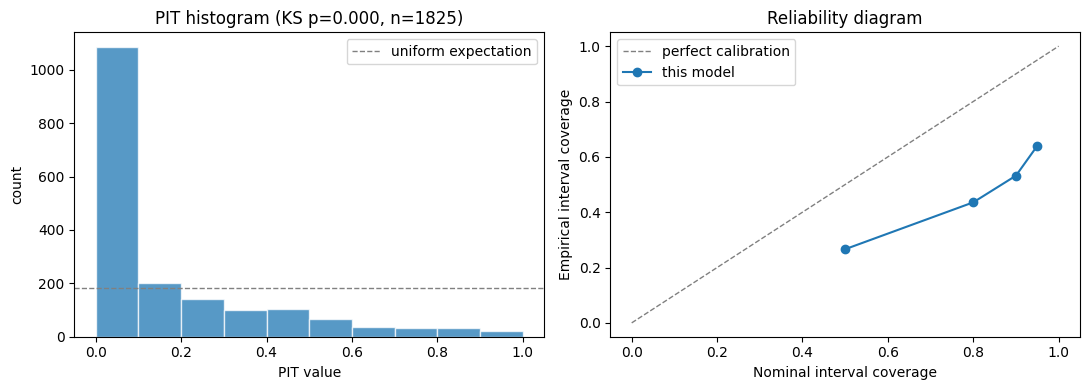

,empirical_coverage
0.5,0.266301
0.8,0.435616
0.9,0.532055
0.95,0.640000


In [ ]:
pit_values = np.array(val['metrics']['pit_values'])
ks = val['metrics']['pit_uniformity_test']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(pit_values, bins=10, range=(0, 1), color='tab:blue', alpha=0.75, edgecolor='white')
axes[0].axhline(len(pit_values) / 10, color='gray', ls='--', lw=1, label='uniform expectation')
axes[0].set_title(f"PIT histogram (KS p={ks['p_value']:.3f}, n={ks['n']})")
axes[0].set_xlabel('PIT value')
axes[0].set_ylabel('count')
axes[0].legend()

coverage = val['metrics']['interval_coverage']
levels = sorted(float(k) for k in coverage)
empirical = [coverage[str(l)] if str(l) in coverage else coverage[l] for l in levels]
axes[1].plot([0, 1], [0, 1], color='gray', ls='--', lw=1, label='perfect calibration')
axes[1].plot(levels, empirical, 'o-', color='tab:blue', label='this model')
axes[1].set_xlabel('Nominal interval coverage')
axes[1].set_ylabel('Empirical interval coverage')
axes[1].set_title('Reliability diagram')
axes[1].legend()

fig.tight_layout()
plt.show()

pd.Series(coverage, name='empirical_coverage').to_frame()

More evidence of systematic over forecasting of case counts. The PIT histogram is heavily concentrated near 0 rather than uniform (KS test p≈0.000, n=1825), meaning observed case counts consistently fall in the lower tail of the models simulated predictive distribution This corroborates the overshoot pattern seen in the residual time series. The reliability diagram shows empirical coverage well below nominal at every interval level, indicating the predictive intervals are too narrow. The model is overconfident and does not capture the true variability in outcomes. Together, these two diagnostics indicate the model has both a directional bias towards over-prediction and an overconfidence problem.

## Proper scoring rules: WIS and CRPS

WIS and CRPS score the whole predictive distribution. For
each interval $k$, with central prediction intervals $[\ell_k^\alpha,
u_k^\alpha]$ at levels $\alpha = 1 - \text{level}$,

$$
\mathrm{WIS}_k = \frac{1}{K+\tfrac12}\left[
\tfrac12 |y_k - m_k| + \sum_{\alpha}\tfrac{\alpha}{2}
\Big( (u_k^\alpha - \ell_k^\alpha) + \tfrac{2}{\alpha}(\ell_k^\alpha - y_k)_+
+ \tfrac{2}{\alpha}(y_k - u_k^\alpha)_+ \Big) \right],
$$

with $m_k$ the posterior predictive median and $K$ the number of levels.
This is a discrete approximation to CRPS built from prediction
intervals, and decomposes additively into sharpness (interval width,
independent of $y_k$), under-prediction penalty, and
over-prediction penalty components.

Estimates CRPS directly from the particle ensemble via
the unbiased pairwise-difference estimator (Gneiting & Raftery, 2007)

$$
\widehat{\mathrm{CRPS}}_k = \frac{1}{P}\sum_p |x^{(p)} - y_k|
- \frac{1}{2P^2}\sum_{p,q} |x^{(p)} - x^{(q)}|,
$$

subsampling the ensemble to max particles when $P$
is large, since the pairwise term is $O(P^2)$. Both scores are
negatively oriented and share units with the case
counts themselves.

In [ ]:
wis = val['metrics']['weighted_interval_score']
crps = val['metrics']['crps']
peak = val['metrics']['peak_timing']

scoring_summary = pd.Series({
    'WIS (mean, cases/interval)': wis['wis_mean'],
    'sharpness component (avg band width)': wis['sharpness_component_mean'],
    'under-prediction penalty': wis['underprediction_component_mean'],
    'over-prediction penalty': wis['overprediction_component_mean'],
    'CRPS (mean, cases/interval)': crps['crps_mean'],
    f"P(model peak within {peak['tolerance_years']}y of observed peak)": peak['prob_peak_within_tolerance'],
    'Median particle peak time (elapsed years)': peak['median_particle_peak_time'],
    'Observed peak time (elapsed years)': peak['observed_peak_time'],
})
scoring_summary.to_frame('value')

,value
"WIS (mean, cases/interval, lower better)",92.117808
sharpness component (avg band width),49.914642
under-prediction penalty,22.373209
over-prediction penalty,0.259486
"CRPS (mean, cases/interval, lower better)",131.792466
P(model peak within 0.25y of observed peak),0.464500
Median particle peak time (elapsed years),1.188227
Observed peak time (elapsed years),0.249144


Interval-based scores confirm the same magnitude problem seen in the raw error metrics. WIS averages 92.1 cases/interval, with the under-prediction penalty (22.4) far exceeding the over-prediction penalty (0.26). Given the validation window plot, this is likely explained by the width and elevation of the posterior predictive band relative to the much lower and noisier observed data. When observations fall below a wide, high band, standard WIS decomposition attributes that to the under-prediction penalty term regardless of the underlying cause. So this breakdown is largely a restatement of the same central-tendency bias already visible in the mean bias and PIT metrics.

## Peak timing distribution across the particle ensemble

Computes, per particle $p$, the interval at
which its simulated trajectory peaks, $\hat t^{(p)} = \arg\max_k
y_k^{(p)}$, and compares the resulting empirical distribution of
$\{\hat t^{(p)}\}$ against the observed peak time $t^\ast$.
Reports the median and interquartile range of $\{\hat t^{(p)}\}$, and
$\Pr\big(|\hat t^{(p)} - t^\ast| \le \texttt{tolerance\_years}\big)$,
the fraction of particles that peak within the tolerance window of
the true peak. This is the ensemble level counterpart to the single
point comparison (sim_peak_idx vs. obs_peak_idx).

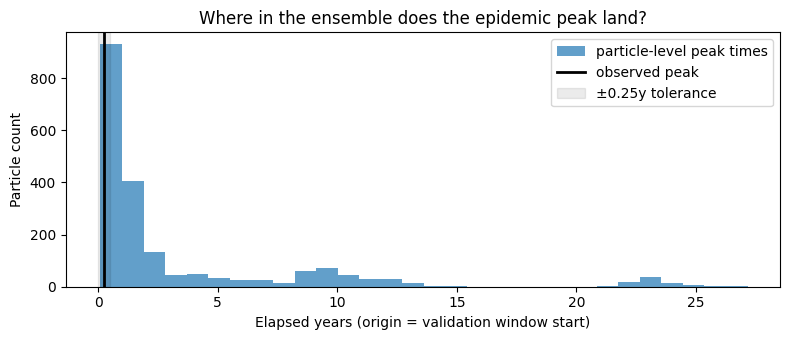

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(peak['particle_peak_times'], bins=30, color='tab:blue', alpha=0.7, label='particle-level peak times')
ax.axvline(peak['observed_peak_time'], color='black', lw=2, label='observed peak')
ax.axvspan(
    peak['observed_peak_time'] - peak['tolerance_years'],
    peak['observed_peak_time'] + peak['tolerance_years'],
    color='black', alpha=0.08, label=f'±{peak['tolerance_years']}y tolerance',
)
ax.set_xlabel('Elapsed years (origin = validation window start)')
ax.set_ylabel('Particle count')
ax.set_title('Where in the ensemble does the epidemic peak land?')
ax.legend()
fig.tight_layout()
plt.show()

The majority of particles peak close to the observed time, but a meaningful minority pull the aggregate statistics far from what the modal behavior suggests. This ensemble-level disagreement ikely contributes to the wide, poorly-calibrated predictive bands seen in the validation window plot as some particles predict correctly while others predict a significantly different epidemic phase.

## Sensitivity to fixed parameters

$\hat\theta$ is held fixed and gamma/sigma/maternal_waning_rate are
perturbed one at a time over $\pm15$-25% of their literature baseline.
The full validation pipeline is rerun at each level.

In [ ]:
calib_start = calib['fit_window']['start']
calib_end = calib['fit_window']['end']
spin_up_years = calib.get('spin_up_years', 0.0)

series = data.load_processed_series()
calib_sim_start = _shift_date_str(calib_start, -spin_up_years) if spin_up_years > 0 else calib_start
calib_fit_series = restrict_date_range(series, calib_sim_start, calib_end)
calib_observed_times = data.series_to_elapsed_years(calib_fit_series)
calib_observed_case_counts = calib_fit_series['case_count'].to_numpy(dtype=float)
fit_window_start_year = float(pd_year(calib_sim_start))
score_start = spin_up_years if spin_up_years > 0 else None
validation_start_year = float(pd_year(calib_end))

birth_rate_fn, death_rate_fn = historical_population.build_vital_rate_functions()
contact_df = contact_matrix.load_processed_contact_matrix(config)
calibration_fixed_parameters = {
    'gamma': config['calibration']['calibration_fixed_parameters']['gamma'],
    'sigma': config['calibration']['calibration_fixed_parameters']['sigma'],
    'maternal_waning_rate': config['calibration']['calibration_fixed_parameters']['maternal_waning_rate'],
    'birth_rate': birth_rate_fn,
    'death_rate': death_rate_fn,
    'vaccination_rates': list(config['calibration']['calibration_fixed_vaccination_rates']),
    'contact_matrix': contact_df.to_numpy(dtype=float),
}

N_PARTICLES = 500
N_LEVELS = 3

SENSITIVITY_RANGES = {
    'gamma': (config['literature']['fixed_gamma_per_year'] * 0.85, config['literature']['fixed_gamma_per_year'] * 1.15),
    'sigma': (config['literature']['fixed_sigma_per_year'] * 0.85, config['literature']['fixed_sigma_per_year'] * 1.15),
    'maternal_waning_rate': (
        config['literature']['fixed_maternal_waning_rate_per_year'] * 0.75,
        config['literature']['fixed_maternal_waning_rate_per_year'] * 1.25,
    ),
}
BASELINE_VALUES = {
    'gamma': config['literature']['fixed_gamma_per_year'],
    'sigma': config['literature']['fixed_sigma_per_year'],
    'maternal_waning_rate': config['literature']['fixed_maternal_waning_rate_per_year'],
}

sensitivity_rows = []

for param_name, (lo, hi) in SENSITIVITY_RANGES.items():
    for level_val in np.linspace(lo, hi, N_LEVELS):
        perturbed_calib_fixed = dict(calibration_fixed_parameters)
        perturbed_calib_fixed[param_name] = float(level_val)

        warm_start_result = validation.capture_calibration_final_cloud(
            theta_hat=calib['theta_hat'],
            observed_times=calib_observed_times,
            observed_case_counts=calib_observed_case_counts,
            fixed_parameters=perturbed_calib_fixed,
            fit_window_start_year=fit_window_start_year,
            n_particles=N_PARTICLES,
            seed=1,
            score_start=score_start,
        )
        calibration_final_cloud = stochastic_model.StochasticParticleCloud.from_states(
            warm_start_result.final_states
        )

        validation_fixed_parameters = validation.build_validation_fixed_parameters(
            perturbed_calib_fixed, validation_start_year=validation_start_year,
        )
        val_rng = np.random.default_rng(2)
        val_result = validation.run_validation(
            theta_hat=calib['theta_hat'],
            calibration_final_cloud=calibration_final_cloud,
            validation_observed_times=validation_times,
            validation_observed_case_counts=observed,
            validation_fixed_parameters=validation_fixed_parameters,
            validation_start_year=validation_start_year,
            rng=val_rng,
            return_final_cloud=False,
        )

        sweep_metrics = validation_metrics.compute_all_metrics(
            case_draws=val_result.simulated_case_draws,
            validation_times=val_result.validation_times,
            observed_case_counts=val_result.observed_case_counts,
            simulated_incidence=val_result.simulated_incidence,
            pit_rng=np.random.default_rng(1002),
        )

        sensitivity_rows.append({
            'parameter': param_name,
            'value': float(level_val),
            'pct_change_from_baseline': 100 * (level_val - BASELINE_VALUES[param_name]) / BASELINE_VALUES[param_name],
            'wis_mean': sweep_metrics['weighted_interval_score']['wis_mean'],
            'crps_mean': sweep_metrics['crps']['crps_mean'],
            'coverage_90': sweep_metrics['interval_coverage'][0.9],
            'log_predictive_density': val_result.log_predictive_density,
            'is_baseline': bool(np.isclose(level_val, BASELINE_VALUES[param_name], rtol=1e-6)),
        })

sens_df = pd.DataFrame(sensitivity_rows)
sens_df

,parameter,value,pct_change_from_baseline,wis_mean,crps_mean,coverage_90,log_predictive_density,is_baseline
0,gamma,38.807812,-15.0,128.962270,185.052022,0.419178,-10150.681549,False
1,gamma,45.656250,0.0,91.664575,130.673169,0.532603,-8744.950263,True
2,gamma,52.504687,15.0,58.779772,81.835439,0.783014,-6892.312772,False
3,sigma,28.223864,-15.0,92.824419,133.185216,0.500274,-8820.427602,False
4,sigma,33.204545,0.0,91.664575,130.673169,0.532603,-8744.950263,True
5,sigma,38.185227,15.0,92.563943,131.822914,0.592329,-8112.733952,False
6,maternal_waning_rate,1.200000,-25.0,87.618913,125.092924,0.566575,-8323.211368,False
7,maternal_waning_rate,1.600000,0.0,91.664575,130.673169,0.532603,-8744.950263,True
8,maternal_waning_rate,2.000000,25.0,95.257851,135.683664,0.521644,-8907.899135,False


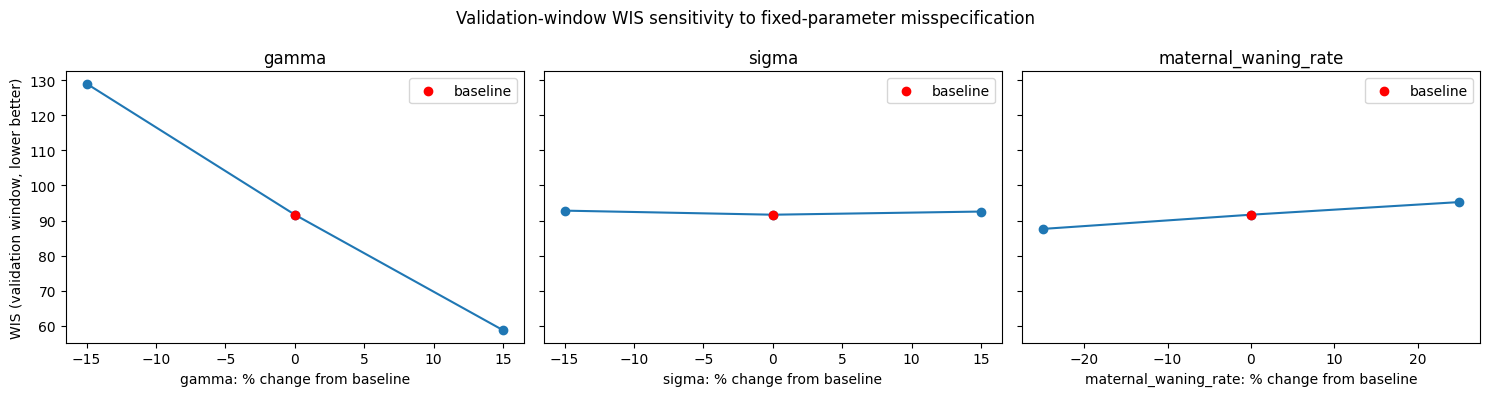

In [ ]:
fig, axes = plt.subplots(1, len(SENSITIVITY_RANGES), figsize=(5 * len(SENSITIVITY_RANGES), 4), sharey=True)
for ax, param_name in zip(axes, SENSITIVITY_RANGES):
    sub = sens_df[sens_df['parameter'] == param_name].sort_values('pct_change_from_baseline')
    ax.plot(sub['pct_change_from_baseline'], sub['wis_mean'], marker='o', color='tab:blue')
    baseline_row = sub[sub['is_baseline']]
    if len(baseline_row):
        ax.scatter(baseline_row['pct_change_from_baseline'], baseline_row['wis_mean'], color='red', zorder=5, label='baseline')
    ax.set_xlabel(f'{param_name}: % change from baseline')
    ax.set_title(param_name)
    ax.legend()
axes[0].set_ylabel('WIS (validation window, lower better)')
fig.suptitle('Validation-window WIS sensitivity to fixed-parameter misspecification')
fig.tight_layout()
plt.show()

Perturbation of three fixed epidemiological parameters reveals that model fit is highly sensitive to $\gamma$, the recovery rate, and comparatively insensitive to the other two. Increasing $\gamma$ by 15% from baseline improves WIS by ~36% (91.7 → 58.8), improves 90% coverage from 0.53 to 0.78, and improves log predictive density by nearly 2000 units while decreasing $\gamma$ by 15% degrades all four metrics by a similar or larger margin. $\sigma$ and $\delta$ show comparatively minor and even non-monotonic effects on these metrics. This suggests the current fixed value of $\gamma$ is a leading candidate for the over-prediction and under coverage failures identified by residual overshoot, PIT concentration near 0, 5–95% coverage of 0.53, peak magnitude ratio of 1.65. A $\gamma$ that is too low relative to the true recovery rate would mechanically produce longer effective infectious periods, larger simulated outbreaks, and greater variance in outbreak trajectories across particles, plausibly also contributing to the heavy tailed peak timing distribution seen in the ensemble diagnostic.